In [1]:
import os
from pathlib import Path
# import time
# from copy import deepcopy

# from tqdm import trange, tqdm

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
# import pandas as pd
from sklearn.decomposition import PCA, IncrementalPCA

from chem_operator.utils import get_mechanism_file, to_numpy, get_species_names
from chem_operator.datasets import (
    CaseParameters, CaseSimulator, SimulationRecord, SimulationDatasetGenerator, ChemOperatorDataset    
)

import torch

from chem_operator.reactors.cstr.dataset_generator import CSTRCaseSimulator

prog_path = Path(os.path.abspath(""))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running Cantera version: {ct.__version__}")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Running Cantera version: 3.2.0


In [11]:
dataset = ChemOperatorDataset(
    path=prog_path.parent / "datasets" / "cstr" / "cstr_non_isothermal_train.h5", # "cstr_train.h5",
    full_trajectory_mode=True,
    dtype=torch.float32
    # n_steps_input=n_steps_input,
    # n_steps_output=n_steps_output,
    # dt_stride=dt_stride,
    # state_variables=state_variables,
    # time_key=time_key,
    # trajectory_parameters=trajectory_parameters,
)

# DataLoader(
#     dataset,
#     batch_size=batch_size,
#     shuffle=shuffle,
#     **kwargs,
# )
len(dataset)

40

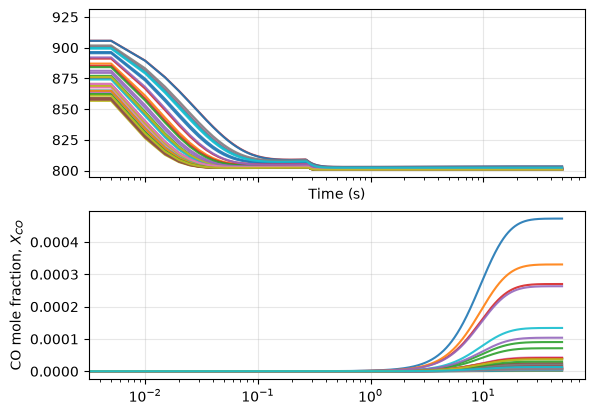

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True) # figsize=(8, 5)

for i in range(len(dataset)):
    sample = dataset[i]

    species_names = get_species_names(sample)
    co_idx = species_names.index("CO")

    t_out = to_numpy(sample["output_coordinates"]["time"])
    T_out = to_numpy(sample["output_fields"]["T"])
    x_out = to_numpy(sample["output_fields"]["X"])[:, co_idx]

    t_in = to_numpy(sample["input_coordinates"]["time"]).reshape(-1)
    T_in = to_numpy(sample["input_fields"]["T"])
    x_in = to_numpy(sample["input_fields"]["X"])[:, co_idx].reshape(-1)

    t = np.concatenate([t_in, t_out])
    T = np.concatenate([T_in, T_out])
    x_co = np.concatenate([x_in, x_out])

    line = ax1.semilogx(t, T, alpha=0.9)
    ax2.semilogx(t, x_co, alpha=0.9)

ax1.set_xlabel("Time (s)")
ax2.set_ylabel(r"CO mole fraction, $X_{CO}$")
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

In [6]:
dataset[0]["input_fields"]["X"].dtype

torch.float32